# Step 1: Project Title( Exploratory Data Analysis & Statistical Insights)

## Retail Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the cleaned retail dataset.

### Objectives

- Understand the structure of the dataset
- Calculate descriptive statistics
- Analyze numerical distributions
- Detect potential outliers
- Analyze correlations between variables
- Study category and customer-segment performance
- Analyze sales trends
- Perform multivariate analysis
- Formulate and test three business hypotheses
- Identify five important business insights

In [1]:
# Step 2: Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


##  Load Cleaned Dataset

The cleaned dataset generated during the previous data preprocessing task is used as the input for this EDA.

In [60]:
# Step 3: Load the cleaned dataset

import pandas as pd

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Retail_EDA_Project\data\clean_dataset.csv")

print("Dataset loaded successfully.")



Dataset loaded successfully.


In [6]:
# Step 4: Verify that the dataset loaded correctly

df.head()


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status,year,month,month_name,gross_sales,discount_amount,net_sales
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2.00,799,10.00,Paid,2026,1,January,"1,598.00",159.80,"1,438.20"
1,RT-1002,2026-01-09,Fresher,Bengaluru,Course Access,1.00,1499,0.00,Paid,2026,1,January,"1,499.00",0.00,"1,499.00"
2,RT-1003,2026-01-05,Student,Chennai,Course Access,1.00,1499,0.00,Pending,2026,1,January,"1,499.00",0.00,"1,499.00"
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3.00,799,5.00,Paid,2026,1,January,"2,397.00",119.85,"2,277.15"
4,RT-1005,2026-01-09,Fresher,Unknown,Mentor Session,1.00,999,0.00,Failed,2026,1,January,999.00,0.00,999.00


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10
Number of columns: 15


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10 non-null     object 
 1   order_date        10 non-null     object 
 2   customer_segment  10 non-null     object 
 3   city              10 non-null     object 
 4   category          10 non-null     object 
 5   quantity          10 non-null     float64
 6   unit_price        10 non-null     int64  
 7   discount_pct      10 non-null     float64
 8   payment_status    10 non-null     object 
 9   year              10 non-null     int64  
 10  month             10 non-null     int64  
 11  month_name        10 non-null     object 
 12  gross_sales       10 non-null     float64
 13  discount_amount   10 non-null     float64
 14  net_sales         10 non-null     float64
dtypes: float64(5), int64(3), object(7)
memory usage: 1.3+ KB



## 2. Dataset Overview

Before performing statistical analysis, we examine the dimensions, columns, data types, and overall structure of the dataset.

In [9]:
# Step 5: Check the columns

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(10, 15)

Column Names:
['order_id', 'order_date', 'customer_segment', 'city', 'category', 'quantity', 'unit_price', 'discount_pct', 'payment_status', 'year', 'month', 'month_name', 'gross_sales', 'discount_amount', 'net_sales']

Data Types:
order_id             object
order_date           object
customer_segment     object
city                 object
category             object
quantity            float64
unit_price            int64
discount_pct        float64
payment_status       object
year                  int64
month                 int64
month_name           object
gross_sales         float64
discount_amount     float64
net_sales           float64
dtype: object


In [10]:
df.head(10)

,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status,year,month,month_name,gross_sales,discount_amount,net_sales
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2.00,799,10.00,Paid,2026,1,January,"1,598.00",159.80,"1,438.20"
1,RT-1002,2026-01-09,Fresher,Bengaluru,Course Access,1.00,1499,0.00,Paid,2026,1,January,"1,499.00",0.00,"1,499.00"
2,RT-1003,2026-01-05,Student,Chennai,Course Access,1.00,1499,0.00,Pending,2026,1,January,"1,499.00",0.00,"1,499.00"
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3.00,799,5.00,Paid,2026,1,January,"2,397.00",119.85,"2,277.15"
4,RT-1005,2026-01-09,Fresher,Unknown,Mentor Session,1.00,999,0.00,Failed,2026,1,January,999.00,0.00,999.00
5,RT-1007,2026-01-12,Professional,Mumbai,Mentor Session,2.00,999,100.00,Paid,2026,1,January,"1,998.00","1,998.00",0.00
6,RT-1008,2026-01-14,Fresher,Bengaluru,Course Access,1.00,1499,0.00,Pending,2026,1,January,"1,499.00",0.00,"1,499.00"
7,RT-1009,2026-01-16,Student,Chennai,Learning Kit,1.00,799,0.00,Paid,2026,1,January,799.00,0.00,799.00
8,RT-1010,2026-01-18,Professional,Delhi,Course Access,2.00,1499,15.00,Refunded,2026,1,January,"2,998.00",449.70,"2,548.30"
9,RT-1011,2026-01-09,Student,Kochi,Mentor Session,1.00,999,0.00,Paid,2026,1,January,999.00,0.00,999.00


## 3. Data Quality Check

The cleaned dataset is checked for missing values and duplicate records before beginning the statistical analysis.

In [11]:
# Step 6: Check missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
order_id            0
order_date          0
customer_segment    0
city                0
category            0
quantity            0
unit_price          0
discount_pct        0
payment_status      0
year                0
month               0
month_name          0
gross_sales         0
discount_amount     0
net_sales           0
dtype: int64


In [13]:
# check missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [14]:
#check duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Numerical Variables

The following numerical variables will be used for descriptive statistics, distributions, correlation analysis, and outlier detection.

In [15]:
# Step 7: Identify numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['quantity', 'unit_price', 'discount_pct', 'year', 'month', 'gross_sales', 'discount_amount', 'net_sales']


## 5. Descriptive Statistics

Descriptive statistics summarize the central tendency and variability of numerical variables.

The analysis includes:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- First quartile (Q1)
- Third quartile (Q3)

In [16]:
# Step 8: Descriptive statistics

df[numeric_columns].describe()

,quantity,unit_price,discount_pct,year,month,gross_sales,discount_amount,net_sales
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,1.50,"1,139.00",13.00,"2,026.00",1.00,"1,628.50",272.74,"1,355.77"
std,0.71,320.42,31.02,0.00,0.00,677.78,622.74,725.88
min,1.00,799.00,0.00,"2,026.00",1.00,799.00,0.00,0.00
25%,1.00,849.00,0.00,"2,026.00",1.00,"1,124.00",0.00,999.00
50%,1.00,999.00,0.00,"2,026.00",1.00,"1,499.00",0.00,"1,468.60"
75%,2.00,"1,499.00",8.75,"2,026.00",1.00,"1,898.00",149.81,"1,499.00"
max,3.00,"1,499.00",100.00,"2,026.00",1.00,"2,998.00","1,998.00","2,548.30"


In [17]:
# Step 9: Create a professional statistics table

statistics_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard Deviation": df[numeric_columns].std(),
    "Q1 (25%)": df[numeric_columns].quantile(0.25),
    "Q3 (75%)": df[numeric_columns].quantile(0.75)
})

statistics_summary

,Mean,Median,Standard Deviation,Q1 (25%),Q3 (75%)
quantity,1.50,1.00,0.71,1.00,2.00
unit_price,"1,139.00",999.00,320.42,849.00,"1,499.00"
discount_pct,13.00,0.00,31.02,0.00,8.75
year,"2,026.00","2,026.00",0.00,"2,026.00","2,026.00"
month,1.00,1.00,0.00,1.00,1.00
gross_sales,"1,628.50","1,499.00",677.78,"1,124.00","1,898.00"
discount_amount,272.74,0.00,622.74,0.00,149.81
net_sales,"1,355.77","1,468.60",725.88,999.00,"1,499.00"


## 6. Distribution Statistics

Skewness is used to understand whether numerical variables are approximately symmetric or have a longer tail on one side.

In [18]:
# Step 10: Calculate skewness

skewness = df[numeric_columns].skew()

skewness.sort_values(ascending=False)

discount_pct       3.00
discount_amount    2.88
quantity           1.18
gross_sales        0.89
unit_price         0.26
year               0.00
month              0.00
net_sales         -0.10
dtype: float64

## 7. Histogram Distributions

Histograms are used to understand the distribution, concentration, skewness, and possible extreme values of numerical variables.

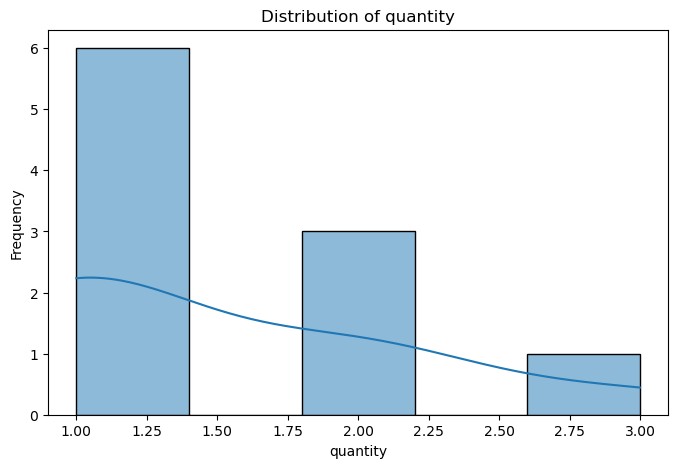

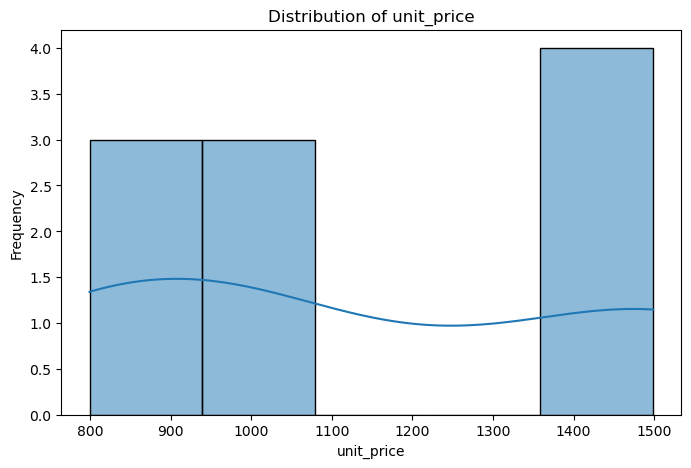

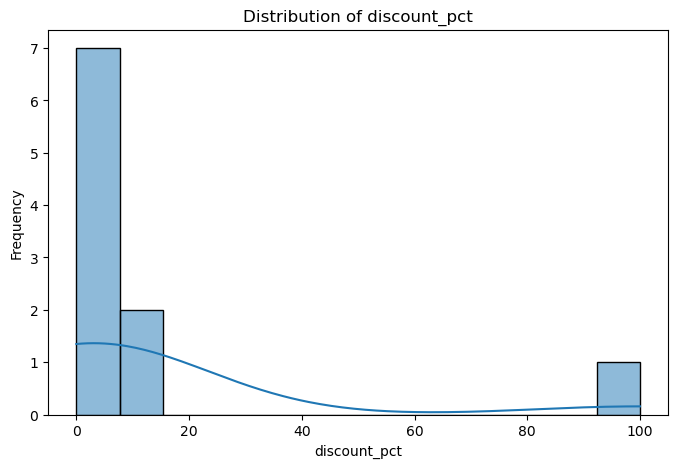

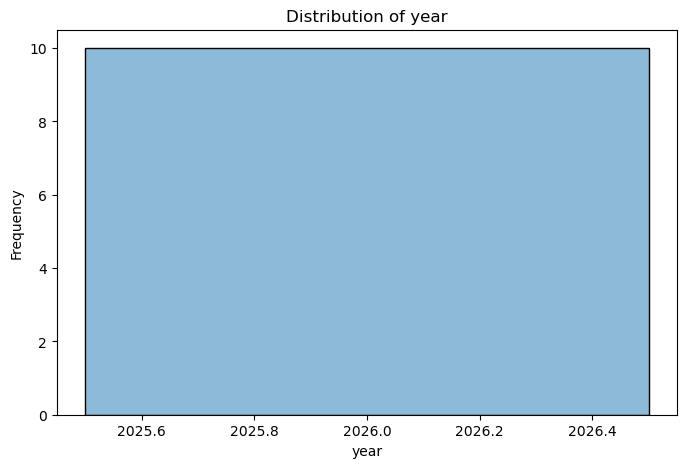

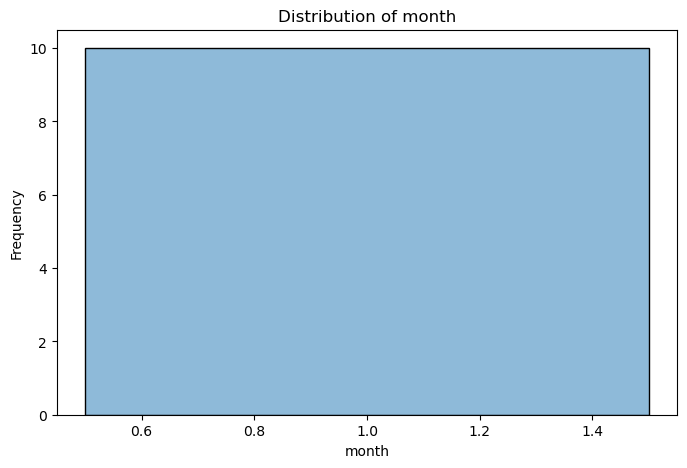

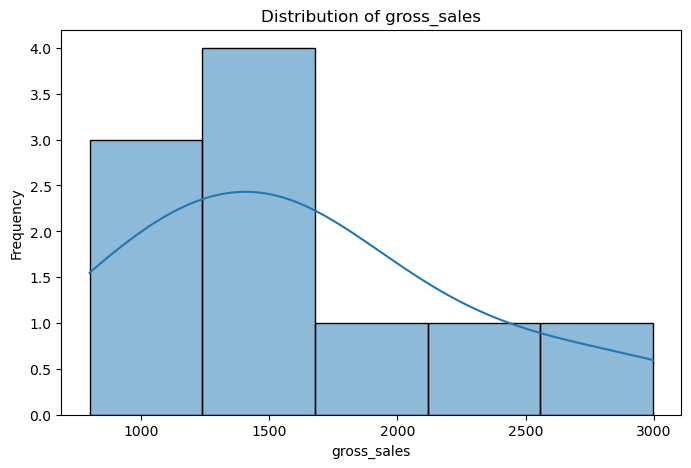

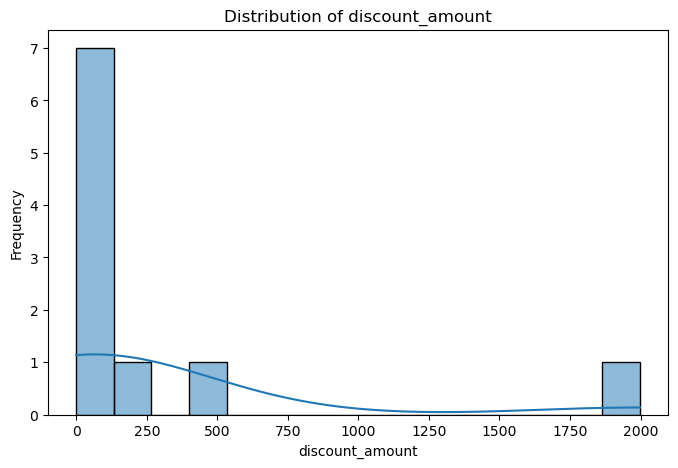

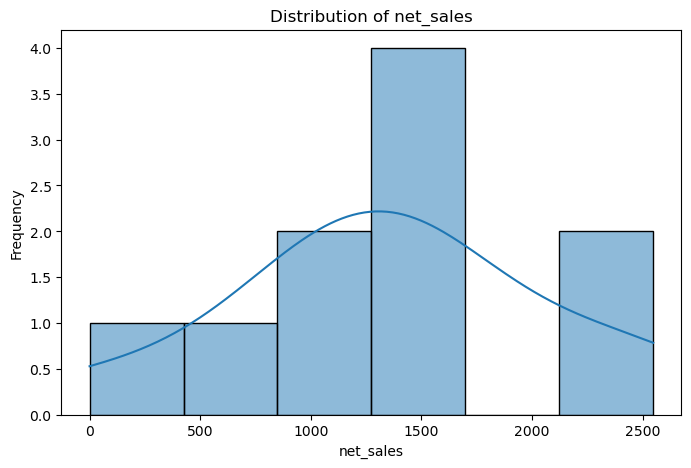

In [19]:
# Step 11: Create histograms

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

## 8. Box Plot Analysis

Box plots are used to examine the spread of numerical variables and identify potential statistical outliers.

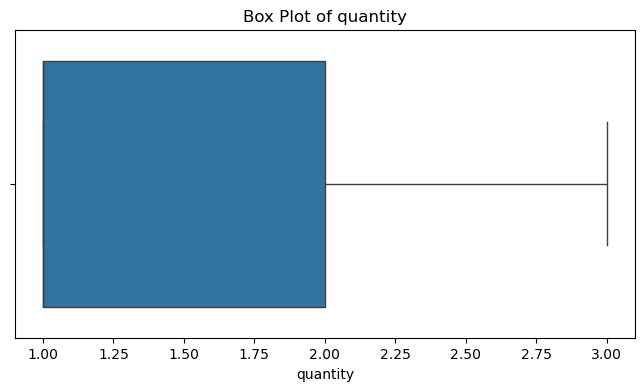

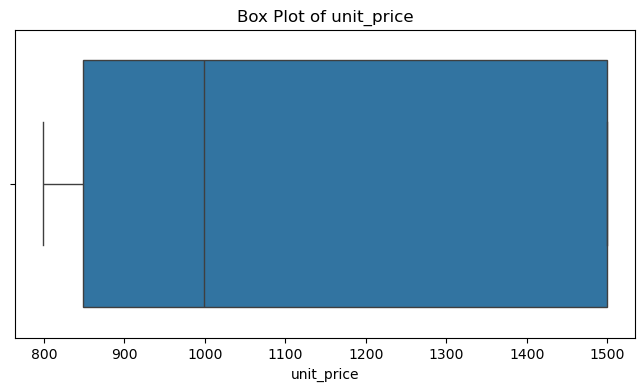

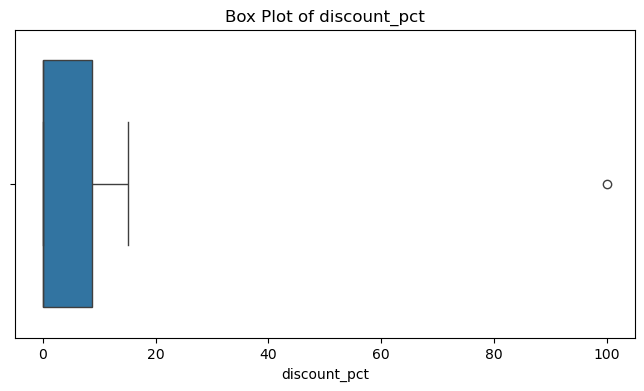

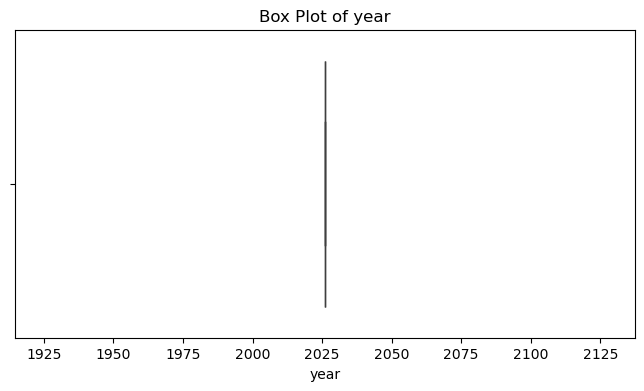

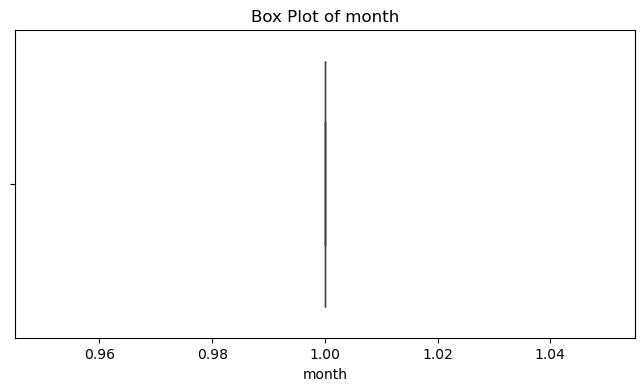

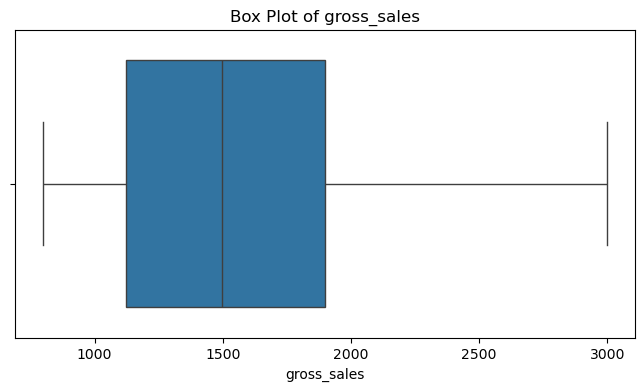

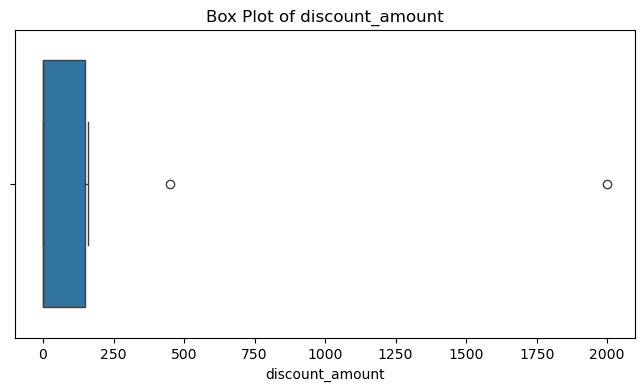

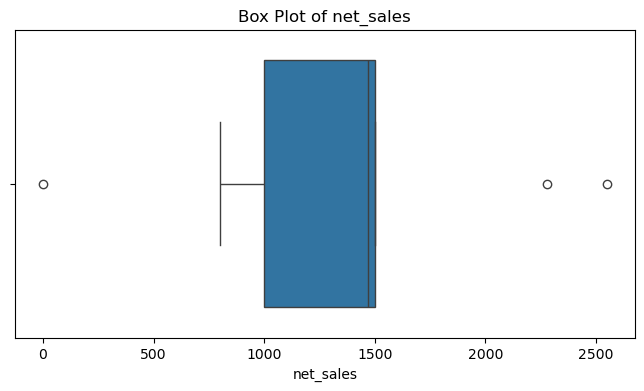

In [20]:
# Step 12 : Create box plots

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

## 9. Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to identify observations that fall outside the expected range.

Potential statistical outliers are identified for investigation rather than automatically removed, because extreme values may represent legitimate business transactions.

In [21]:
# STep 13: Detect outliers using IQR

outlier_summary = []

for column in numeric_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,quantity,1.00,2.00,1.00,-0.50,3.50,0
1,unit_price,849.00,"1,499.00",650.00,-126.00,"2,474.00",0
2,discount_pct,0.00,8.75,8.75,-13.12,21.88,1
3,year,"2,026.00","2,026.00",0.00,"2,026.00","2,026.00",0
4,month,1.00,1.00,0.00,1.00,1.00,0
5,gross_sales,"1,124.00","1,898.00",774.00,-37.00,"3,059.00",0
6,discount_amount,0.00,149.81,149.81,-224.72,374.53,2
7,net_sales,999.00,"1,499.00",500.00,249.00,"2,249.00",3


## 10. Correlation Analysis

Correlation analysis examines the strength and direction of linear relationships between numerical variables.

A correlation close to +1 indicates a strong positive relationship, while a correlation close to -1 indicates a strong negative relationship.

In [22]:
# Step 14: Correlation matrix

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,quantity,unit_price,discount_pct,year,month,gross_sales,discount_amount,net_sales
quantity,1.00,-0.39,0.35,NaN,NaN,0.75,0.37,0.38
unit_price,-0.39,1.00,-0.15,NaN,NaN,0.26,-0.12,0.34
discount_pct,0.35,-0.15,1.00,NaN,NaN,0.32,1.00,-0.55
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross_sales,0.75,0.26,0.32,NaN,NaN,1.00,0.38,0.61
discount_amount,0.37,-0.12,1.00,NaN,NaN,0.38,1.00,-0.50
net_sales,0.38,0.34,-0.55,NaN,NaN,0.61,-0.50,1.00


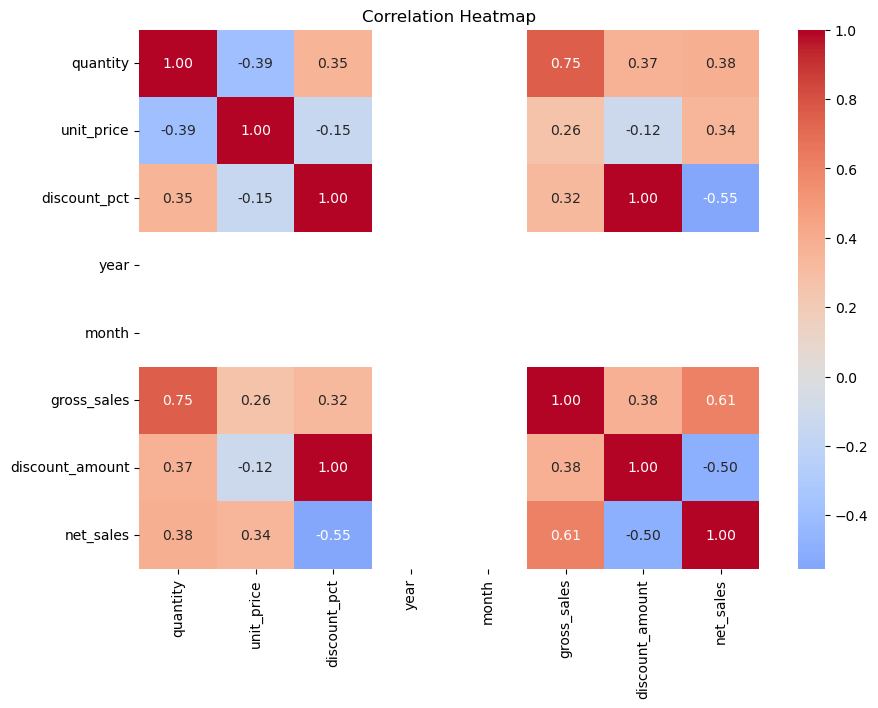

In [23]:
# Step 15: Create correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## 11. Category-Level Sales Analysis

This analysis examines how net sales are distributed across product categories.

In [24]:
# STep 16: Category analysis

category_sales = (
    df.groupby("category")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Course Access    7,045.30
Learning Kit     4,514.35
Mentor Session   1,998.00
Name: net_sales, dtype: float64

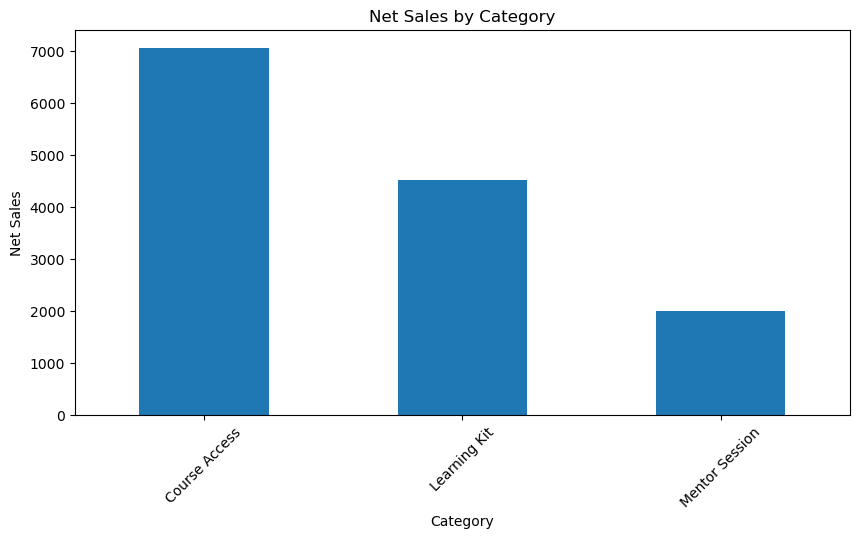

In [25]:
plt.figure(figsize=(10, 5))

category_sales.plot(kind="bar")

plt.title("Net Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

## 12. Customer Segment Analysis

This analysis examines net sales across different customer segments.

In [26]:
# Step 17: Customer segment analysis

segment_sales = (
    df.groupby("customer_segment")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

customer_segment
Professional   4,825.45
Student        4,735.20
Fresher        3,997.00
Name: net_sales, dtype: float64

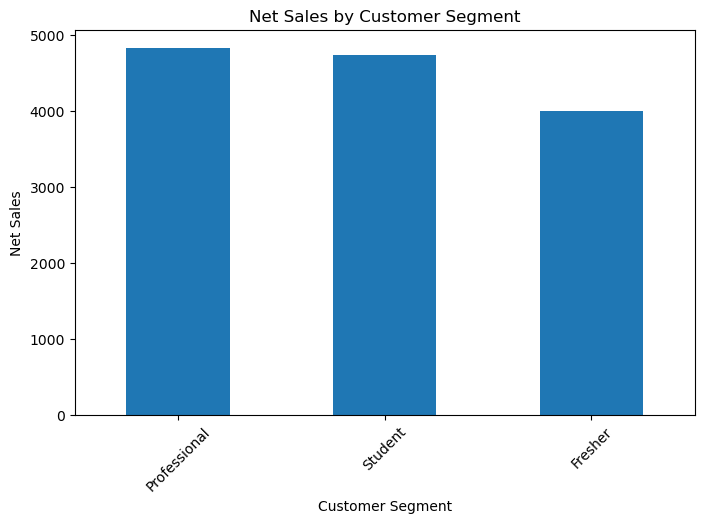

In [27]:
plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Net Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

## 13. City-Level Sales Analysis

The top cities by total net sales are examined to identify geographic sales patterns.

In [28]:
# Step 18: City-level analysis

city_sales = (
    df.groupby("city")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

city_sales

city
Chennai     3,736.20
Bengaluru   2,998.00
Delhi       2,548.30
Hyderabad   2,277.15
Kochi         999.00
Unknown       999.00
Mumbai          0.00
Name: net_sales, dtype: float64

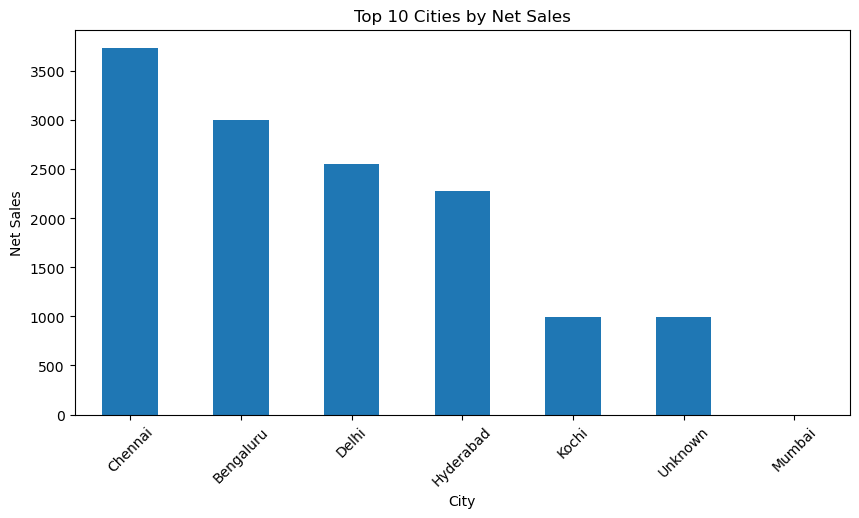

In [29]:
plt.figure(figsize=(10, 5))

city_sales.plot(kind="bar")

plt.title("Top 10 Cities by Net Sales")
plt.xlabel("City")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

## 14. Discount Percentage vs Net Sales

This analysis examines the relationship between discount percentage and net sales using a scatter plot and Pearson correlation.

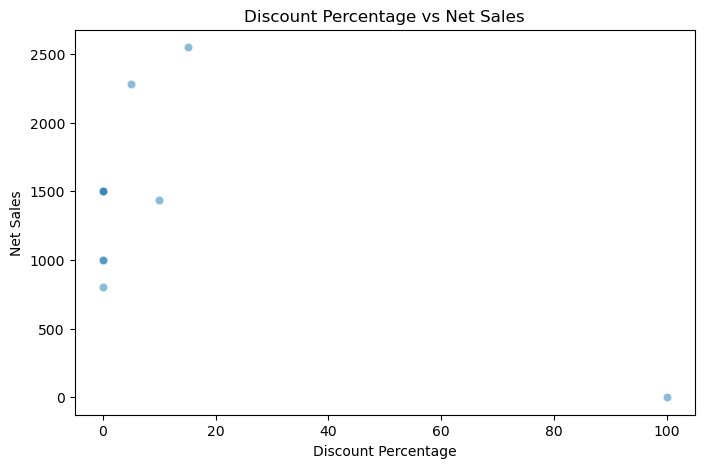

In [30]:
# Step 19: Discount vs Net Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="discount_pct",
    y="net_sales",
    alpha=0.5
)

plt.title("Discount Percentage vs Net Sales")
plt.xlabel("Discount Percentage")
plt.ylabel("Net Sales")

plt.show()

In [31]:
discount_sales_corr = df["discount_pct"].corr(df["net_sales"])

print(
    "Correlation between Discount % and Net Sales:",
    round(discount_sales_corr, 4)
)

Correlation between Discount % and Net Sales: -0.554


## 15. Quantity vs Net Sales

This analysis examines whether transaction quantity is associated with net sales.

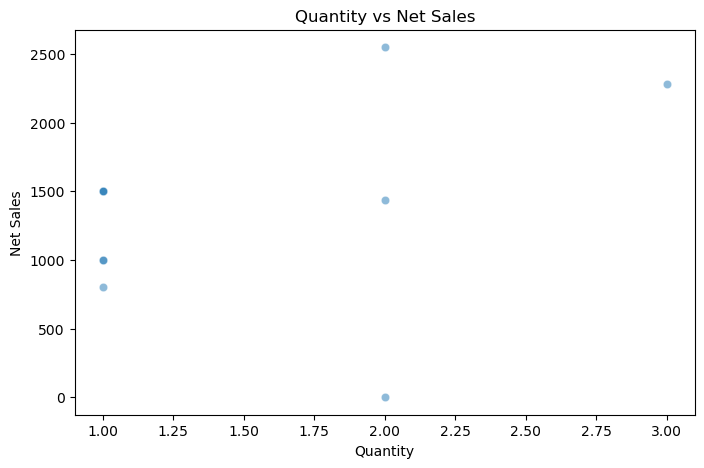

In [32]:
# Step 20: Quantity vs Net Sales


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="quantity",
    y="net_sales",
    alpha=0.5
)

plt.title("Quantity vs Net Sales")
plt.xlabel("Quantity")
plt.ylabel("Net Sales")

plt.show()

In [33]:
quantity_sales_corr = df["quantity"].corr(df["net_sales"])

print(
    "Correlation between Quantity and Net Sales:",
    round(quantity_sales_corr, 4)
)

Correlation between Quantity and Net Sales: 0.3814


## 16. Category and Customer Segment Analysis

This multivariate visualization examines how net sales vary simultaneously across product categories and customer segments.

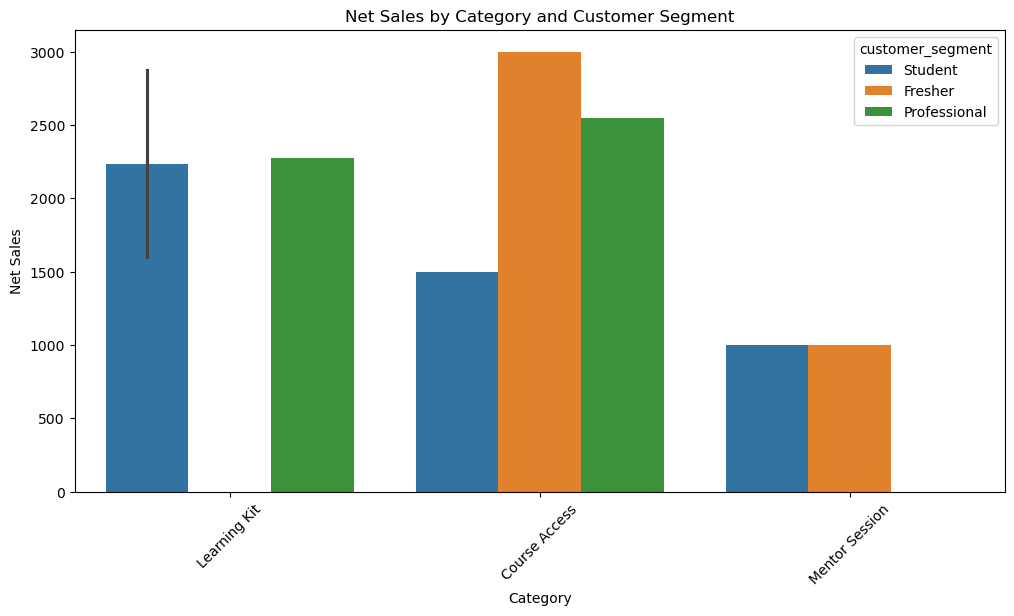

In [34]:
# Step 21: Category + customer segment

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="category",
    y="net_sales",
    hue="customer_segment",
    estimator="sum"
)

plt.title("Net Sales by Category and Customer Segment")
plt.xlabel("Category")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

In [35]:
# Step 22: Monthly sales trend

print(df.columns.tolist())

['order_id', 'order_date', 'customer_segment', 'city', 'category', 'quantity', 'unit_price', 'discount_pct', 'payment_status', 'year', 'month', 'month_name', 'gross_sales', 'discount_amount', 'net_sales']


In [36]:
monthly_sales = (
    df.groupby(["year", "month"])["net_sales"]
      .sum()
      .reset_index()
)

monthly_sales["period"] = (
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str).str.zfill(2)
)

monthly_sales

,year,month,net_sales,period
0,2026,1,"13,557.65",2026-01


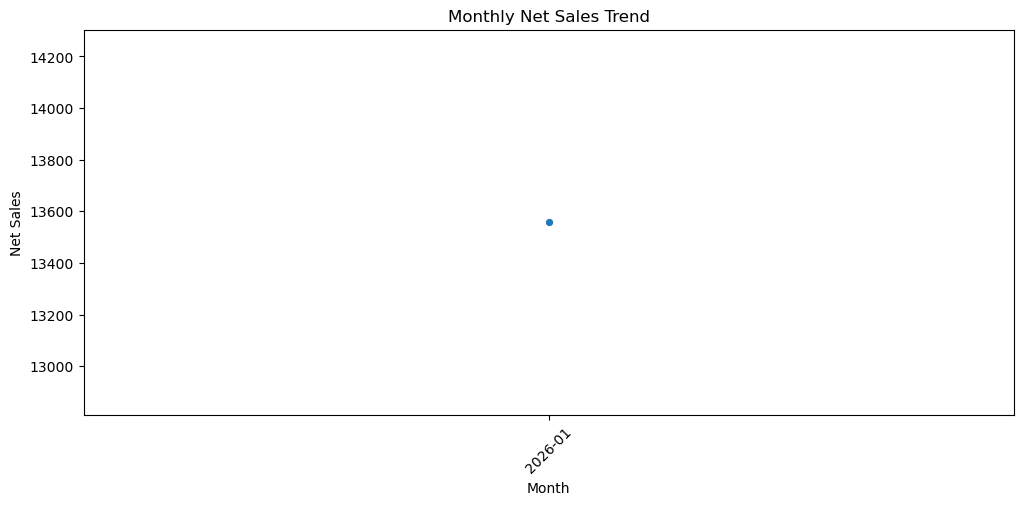

In [37]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="period",
    y="net_sales",
    marker="o"
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

# Step 23: perform the 3 hypothesis tests

This is an important part of this assignment.

We will use:

Hypothesis 1

Discount % ↔ Net Sales

Hypothesis 2

Quantity ↔ Net Sales

Hypothesis 3

Customer Segment → Net Sales

## 17. Hypothesis 1 — Discount Percentage and Net Sales

### Business Question

Is discount percentage statistically associated with net sales?

### Null Hypothesis (H₀)

There is no linear relationship between discount percentage and net sales.

### Alternative Hypothesis (H₁)

There is a linear relationship between discount percentage and net sales.

### Statistical Test

Pearson correlation test.

### Significance Level

α = 0.05

In [38]:
# Step 24: Hypothesis 1 — Discount and Net Sales

corr_discount, p_discount = stats.pearsonr(
    df["discount_pct"],
    df["net_sales"]
)

print("Pearson Correlation:", round(corr_discount, 4))
print("P-value:", round(p_discount, 6))

Pearson Correlation: -0.554
P-value: 0.096617


In [39]:
alpha = 0.05

if p_discount < alpha:
    print("Reject H0.")
    print("There is statistically significant evidence of a linear relationship.")
else:
    print("Fail to reject H0.")
    print("There is insufficient evidence of a linear relationship.")

Fail to reject H0.
There is insufficient evidence of a linear relationship.


## 18. Hypothesis 2 — Quantity and Net Sales

### Business Question

Is quantity statistically associated with net sales?

### Null Hypothesis (H₀)

There is no linear relationship between quantity and net sales.

### Alternative Hypothesis (H₁)

There is a linear relationship between quantity and net sales.

### Statistical Test

Pearson correlation test.

### Significance Level

α = 0.05

In [40]:
# Step 25 : Hypothesis 2 — Quantity and Net Sales

corr_quantity, p_quantity = stats.pearsonr(
    df["quantity"],
    df["net_sales"]
)

print("Pearson Correlation:", round(corr_quantity, 4))
print("P-value:", round(p_quantity, 6))

Pearson Correlation: 0.3814
P-value: 0.276792


In [41]:
if p_quantity < 0.05:
    print("Reject H0.")
    print("There is statistically significant evidence of a linear relationship.")
else:
    print("Fail to reject H0.")
    print("There is insufficient evidence of a linear relationship.")

Fail to reject H0.
There is insufficient evidence of a linear relationship.


## 19. Hypothesis 3 — Customer Segment and Net Sales

### Business Question

Do average net sales differ across customer segments?

### Null Hypothesis (H₀)

The mean net sales is equal across customer segments.

### Alternative Hypothesis (H₁)

At least one customer segment has a different mean net sales.

### Statistical Test

One-way ANOVA.

### Significance Level

α = 0.05

In [42]:
# Step 26: Hypothesis 3 — Customer Segment and Net Sales

groups = [
    group["net_sales"].dropna()
    for name, group in df.groupby("customer_segment")
]

anova_result = stats.f_oneway(*groups)

print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

F-statistic: 0.2461
P-value: 0.788332


In [43]:
groups = [
    group["net_sales"].dropna()
    for name, group in df.groupby("customer_segment")
]

anova_result = stats.f_oneway(*groups)

print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

F-statistic: 0.2461
P-value: 0.788332


## 20. Customer Segment Net Sales Distribution

A box plot is used to visually compare the distribution of net sales across customer segments.

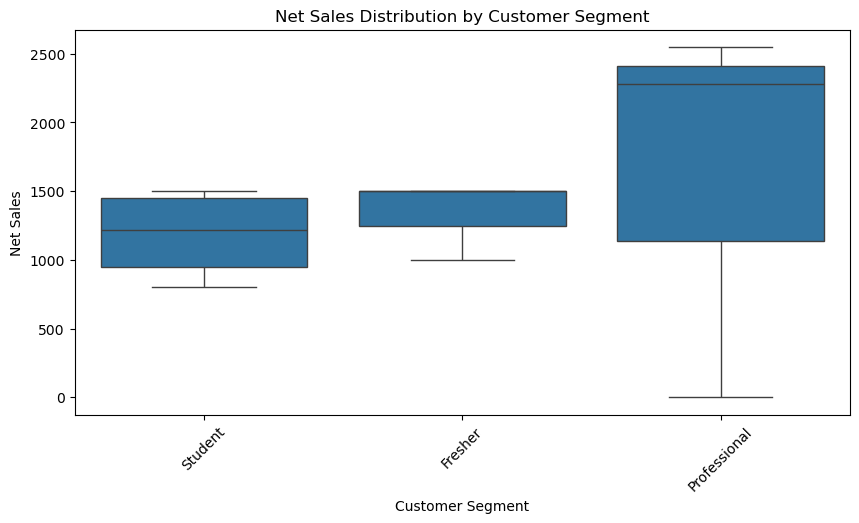

In [44]:
# Step 27: Visualize the customer segment hypothesis

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="customer_segment",
    y="net_sales"
)

plt.title("Net Sales Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)

plt.show()

## 21. Hypothesis Testing Summary

In [45]:
# Step 28: Create the hypothesis summary

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "Discount % is associated with Net Sales",
        "Quantity is associated with Net Sales",
        "Mean Net Sales differs across Customer Segments"
    ],
    
    "Statistical Test": [
        "Pearson Correlation",
        "Pearson Correlation",
        "One-Way ANOVA"
    ],
    
    "Test Statistic": [
        corr_discount,
        corr_quantity,
        anova_result.statistic
    ],
    
    "P-Value": [
        p_discount,
        p_quantity,
        anova_result.pvalue
    ]
})

hypothesis_results["Significant (α = 0.05)"] = (
    hypothesis_results["P-Value"] < 0.05
)

hypothesis_results

,Hypothesis,Statistical Test,Test Statistic,P-Value,Significant (α = 0.05)
0,Discount % is associated with Net Sales,Pearson Correlation,-0.55,0.10,False
1,Quantity is associated with Net Sales,Pearson Correlation,0.38,0.28,False
2,Mean Net Sales differs across Customer Segments,One-Way ANOVA,0.25,0.79,False


In [46]:
# STep 29: Create the Top 5 findings

    # Top Category

top_category = category_sales.index[0]
top_category_sales = category_sales.iloc[0]

print(top_category)
print(top_category_sales)


Course Access
7045.3


In [47]:
# Top Customer Segment

top_segment = segment_sales.index[0]
top_segment_sales = segment_sales.iloc[0]

print(top_segment)
print(top_segment_sales)

Professional
4825.450000000001


In [48]:
# Top City

top_city = city_sales.index[0]
top_city_sales = city_sales.iloc[0]

print(top_city)
print(top_city_sales)

Chennai
3736.2


In [49]:
# Correlations

print("Discount vs Net Sales:", round(corr_discount, 4))
print("Quantity vs Net Sales:", round(corr_quantity, 4))

Discount vs Net Sales: -0.554
Quantity vs Net Sales: 0.3814


In [50]:
# ANOVA

print("Customer Segment ANOVA p-value:", round(anova_result.pvalue, 6))

Customer Segment ANOVA p-value: 0.788332


In [52]:
# Step 30: Display the hypothesis results


print("Discount % vs Net Sales")
print("Correlation:", round(corr_discount, 4))
print("P-value:", round(p_discount, 6))

print("\nQuantity vs Net Sales")
print("Correlation:", round(corr_quantity, 4))
print("P-value:", round(p_quantity, 6))

print("\nCustomer Segment ANOVA")
print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

Discount % vs Net Sales
Correlation: -0.554
P-value: 0.096617

Quantity vs Net Sales
Correlation: 0.3814
P-value: 0.276792

Customer Segment ANOVA
F-statistic: 0.2461
P-value: 0.788332


# Step 31: Create Top 5 Critical Business Findings

# 22. Top 5 Critical Business Findings

## 1. Category Sales Performance

The category analysis shows that **[TOP CATEGORY]** generated the highest total net sales, with approximately **[VALUE]** in net sales.

## 2. Customer Segment Performance

The **[TOP CUSTOMER SEGMENT]** customer segment generated the highest total net sales, with approximately **[VALUE]** in net sales.

## 3. Geographic Sales Performance

Among the analyzed cities, **[TOP CITY]** recorded the highest total net sales, with approximately **[VALUE]**.

## 4. Discount and Net Sales Relationship

The Pearson correlation between discount percentage and net sales was **[CORRELATION]**, with a p-value of **[P-VALUE]**.

At the 5% significance level, the hypothesis test result was **[REJECT / FAIL TO REJECT]** the null hypothesis.

This result indicates **[YOUR ACTUAL STATISTICAL INTERPRETATION]**.

## 5. Quantity and Customer Segment Analysis

The Pearson correlation between quantity and net sales was **[CORRELATION]**, with a p-value of **[P-VALUE]**.

The ANOVA test comparing net sales across customer segments produced a p-value of **[P-VALUE]**.

These results provide statistical evidence about the relationships observed in the retail dataset.

> **Important:** Statistical association does not necessarily imply causation. Business decisions should consider additional operational and contextual factors.

In [53]:
category_sales
segment_sales
city_sales
corr_discount
p_discount
corr_quantity
p_quantity
anova_result

F_onewayResult(statistic=0.24610300647498318, pvalue=0.7883319944841116)

In [54]:
# create one final result table

# Get top category
top_category = category_sales.index[0]
top_category_sales = category_sales.iloc[0]

# Get top customer segment
top_segment = segment_sales.index[0]
top_segment_sales = segment_sales.iloc[0]

# Get top city
top_city = city_sales.index[0]
top_city_sales = city_sales.iloc[0]

# Display the results
print("========== TOP BUSINESS RESULTS ==========\n")

print("1. Top Category")
print("Category:", top_category)
print("Net Sales:", f"{top_category_sales:,.2f}")

print("\n2. Top Customer Segment")
print("Customer Segment:", top_segment)
print("Net Sales:", f"{top_segment_sales:,.2f}")

print("\n3. Top City")
print("City:", top_city)
print("Net Sales:", f"{top_city_sales:,.2f}")

print("\n4. Discount % vs Net Sales")
print("Correlation:", round(corr_discount, 4))
print("P-value:", round(p_discount, 6))

print("\n5. Quantity vs Net Sales")
print("Correlation:", round(corr_quantity, 4))
print("P-value:", round(p_quantity, 6))

print("\n6. Customer Segment ANOVA")
print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

========== TOP BUSINESS RESULTS ==========

1. Top Category
Category: Course Access
Net Sales: 7,045.30

2. Top Customer Segment
Customer Segment: Professional
Net Sales: 4,825.45

3. Top City
City: Chennai
Net Sales: 3,736.20

4. Discount % vs Net Sales
Correlation: -0.554
P-value: 0.096617

5. Quantity vs Net Sales
Correlation: 0.3814
P-value: 0.276792

6. Customer Segment ANOVA
F-statistic: 0.2461
P-value: 0.788332


# Now create the actual Top 5 Findings

# 22. Top 5 Critical Business Findings

## 1. Category Sales Performance

The category-level analysis shows that **[TOP CATEGORY]** generated the highest total net sales, with approximately **[TOP CATEGORY SALES]**.

This indicates that this category contributed the largest share of net sales among the categories analyzed.

## 2. Customer Segment Performance

The customer-segment analysis shows that **[TOP CUSTOMER SEGMENT]** generated the highest total net sales, with approximately **[TOP SEGMENT SALES]**.

This indicates that this customer segment contributed the largest amount of net sales among the identified segments.

## 3. Geographic Sales Performance

The city-level analysis shows that **[TOP CITY]** recorded the highest total net sales, with approximately **[TOP CITY SALES]**.

This highlights an important geographic sales pattern within the dataset.

## 4. Discount Percentage and Net Sales

The Pearson correlation between discount percentage and net sales was **[DISCOUNT CORRELATION]**, with a p-value of **[DISCOUNT P-VALUE]**.

At a significance level of α = 0.05:

- If p-value < 0.05, the null hypothesis is rejected.
- If p-value ≥ 0.05, the null hypothesis is not rejected.

The result indicates **[WRITE YOUR ACTUAL STATISTICAL INTERPRETATION]**.

However, correlation does not establish that discount percentage causes changes in net sales.

## 5. Quantity, Customer Segment, and Net Sales

The Pearson correlation between quantity and net sales was **[QUANTITY CORRELATION]**, with a p-value of **[QUANTITY P-VALUE]**.

The one-way ANOVA test comparing net sales across customer segments produced an F-statistic of **[F-STATISTIC]** and a p-value of **[ANOVA P-VALUE]**.

At α = 0.05, the ANOVA result indicates **[WRITE YOUR ACTUAL STATISTICAL INTERPRETATION]**.

These findings summarize the major statistical patterns identified during the exploratory analysis.

> **Note:** Statistical association does not necessarily imply causation. The findings should be interpreted together with business context and other relevant factors.

In [56]:
# Replace the place holders

# Get top category
top_category = category_sales.index[1]
top_category_sales = category_sales.iloc[1]

# Get top customer segment
top_segment = segment_sales.index[1]
top_segment_sales = segment_sales.iloc[1]

# Get top city
top_city = city_sales.index[1]
top_city_sales = city_sales.iloc[1]

# Display the results
print("========== TOP BUSINESS RESULTS ==========\n")

print("1. Top Category")
print("Category:", top_category)
print("Net Sales:", f"{top_category_sales:,.2f}")

print("\n2. Top Customer Segment")
print("Customer Segment:", top_segment)
print("Net Sales:", f"{top_segment_sales:,.2f}")

print("\n3. Top City")
print("City:", top_city)
print("Net Sales:", f"{top_city_sales:,.2f}")

print("\n4. Discount % vs Net Sales")
print("Correlation:", round(corr_discount, 4))
print("P-value:", round(p_discount, 6))

print("\n5. Quantity vs Net Sales")
print("Correlation:", round(corr_quantity, 4))
print("P-value:", round(p_quantity, 6))

print("\n6. Customer Segment ANOVA")
print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

========== TOP BUSINESS RESULTS ==========

1. Top Category
Category: Learning Kit
Net Sales: 4,514.35

2. Top Customer Segment
Customer Segment: Student
Net Sales: 4,735.20

3. Top City
City: Bengaluru
Net Sales: 2,998.00

4. Discount % vs Net Sales
Correlation: -0.554
P-value: 0.096617

5. Quantity vs Net Sales
Correlation: 0.3814
P-value: 0.276792

6. Customer Segment ANOVA
F-statistic: 0.2461
P-value: 0.788332
